#  MOBILE PHONE PRICE PREDICTION -LINEAR REGRESSION

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import drive


In [ ]:
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = "/content/drive/MyDrive/ML_LAB/TheoryAss-1/Mobile phone price.csv"
df = pd.read_csv(file_path)
print("Dataset loaded successfully!")
print(df.head(), "\nShape:", df.shape)

Dataset loaded successfully!
     Brand              Model Storage    RAM  Screen Size (inches)  \
0    Apple      iPhone 13 Pro   128 GB   6 GB                  6.1   
1  Samsung   Galaxy S21 Ultra   256 GB  12 GB                  6.8   
2  OnePlus              9 Pro   128 GB   8 GB                  6.7   
3   Xiaomi  Redmi Note 10 Pro   128 GB   6 GB                 6.67   
4   Google            Pixel 6   128 GB   8 GB                  6.4   

          Camera (MP)  Battery Capacity (mAh) Price ($)  
0        12 + 12 + 12                    3095       999  
1  108 + 10 + 10 + 12                    5000      1199  
2     48 + 50 + 8 + 2                    4500       899  
3      64 + 8 + 5 + 2                    5020       279  
4           50 + 12.2                    4614       799   
Shape: (407, 8)


In [ ]:
# Data Cleaning
for col in df.columns:
    df[col] = df[col].astype(str).str.strip()

if 'Price ($)' in df.columns:
    df['Price ($)'] = df['Price ($)'].str.replace(r'[^0-9.]', '', regex=True)
    df['Price ($)'] = pd.to_numeric(df['Price ($)'], errors='coerce')

for col in df.columns:
    if 'RAM' in col or 'Storage' in col:
        df[col] = df[col].str.replace(r'[^0-9.]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

def camera_sum(x):
    parts = str(x).replace('+', ' ').split()
    return sum(float(p) for p in parts if p.replace('.', '', 1).isdigit())

if 'Camera (MP)' in df.columns:
    df['Camera (MP)'] = df['Camera (MP)'].apply(camera_sum)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

df.dropna(inplace=True)

df = pd.get_dummies(df, drop_first=True)
print("\n Converted categorical features to numeric.")
print("Columns after encoding:", len(df.columns))


 Converted categorical features to numeric.
Columns after encoding: 298


/tmp/ipython-input-3510753484.py:22: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [ ]:
target_col = 'Price ($)'
if target_col not in df.columns:
    raise ValueError("Target column not found after encoding.")

y = df[target_col].astype(float).values.reshape(-1, 1)
X = df.drop(columns=[target_col]).astype(float).values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Add bias term
X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_b  = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

print("\nTrain shape:", X_train_b.shape, "| Test shape:", X_test_b.shape)


Train shape: (325, 298) | Test shape: (82, 298)



 Closed-form solution results:
MSE: 31650.999946238222
R² Score: 0.6536478817050896


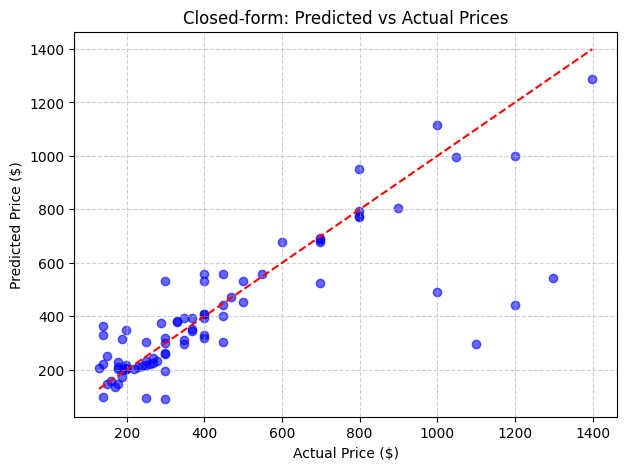

In [ ]:

# CLOSED-FORM SOLUTION (Normal Equation)

theta_closed = np.linalg.pinv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train
y_pred_closed = X_test_b @ theta_closed

mse_closed = mean_squared_error(y_test, y_pred_closed)
r2_closed = r2_score(y_test, y_pred_closed)

print("\n Closed-form solution results:")
print("MSE:", mse_closed)
print("R² Score:", r2_closed)

# Predicted vs Actual plot
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred_closed, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Closed-form: Predicted vs Actual Prices")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()





 Gradient Descent results:
MSE: 25294.276617091717
R² Score: 0.7232085462719049


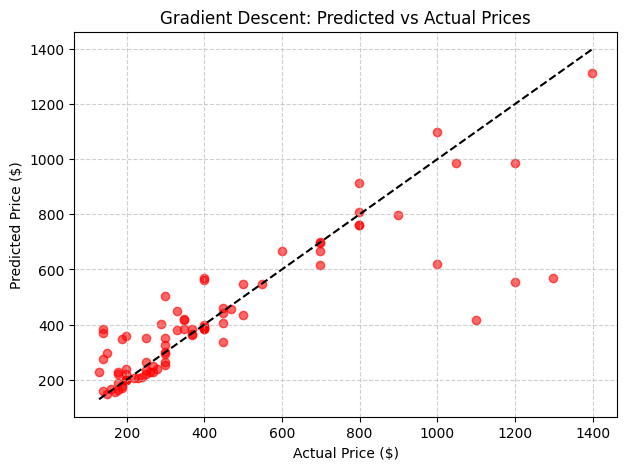

In [ ]:
#  GRADIENT DESCENT
def gradient_descent(X, y, lr=0.01, epochs=2000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    for epoch in range(epochs):
        gradient = (2/m) * X.T @ (X @ theta - y)
        theta -= lr * gradient
    return theta

theta_gd = gradient_descent(X_train_b, y_train, lr=0.01, epochs=2000)
y_pred_gd = X_test_b @ theta_gd

mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print("\n Gradient Descent results:")
print("MSE:", mse_gd)
print("R² Score:", r2_gd)

# Predicted vs Actual plot
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred_gd, color='red', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Gradient Descent: Predicted vs Actual Prices")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()




 Ridge Regression results (Best λ = 100):
Best R² Score: 0.7622474523933231


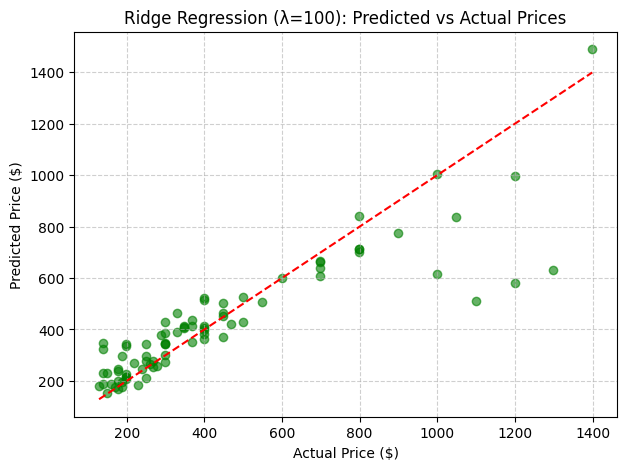

In [ ]:
#  RIDGE REGRESSION (L2 Regularization)

def ridge_closed_form(X, y, lambda_):
    n = X.shape[1]
    I = np.eye(n)
    I[0,0] = 0
    return np.linalg.pinv(X.T @ X + lambda_ * I) @ X.T @ y

lambdas = [0, 0.1, 1, 10, 100]
r2_scores = []

for lam in lambdas:
    theta_ridge = ridge_closed_form(X_train_b, y_train, lam)
    y_pred_ridge = X_test_b @ theta_ridge
    r2 = r2_score(y_test, y_pred_ridge)
    r2_scores.append(r2)

best_lambda = lambdas[np.argmax(r2_scores)]
theta_best = ridge_closed_form(X_train_b, y_train, best_lambda)
y_pred_best = X_test_b @ theta_best

print(f"\n Ridge Regression results (Best λ = {best_lambda}):")
print("Best R² Score:", max(r2_scores))

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred_best, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title(f"Ridge Regression (λ={best_lambda}): Predicted vs Actual Prices")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()



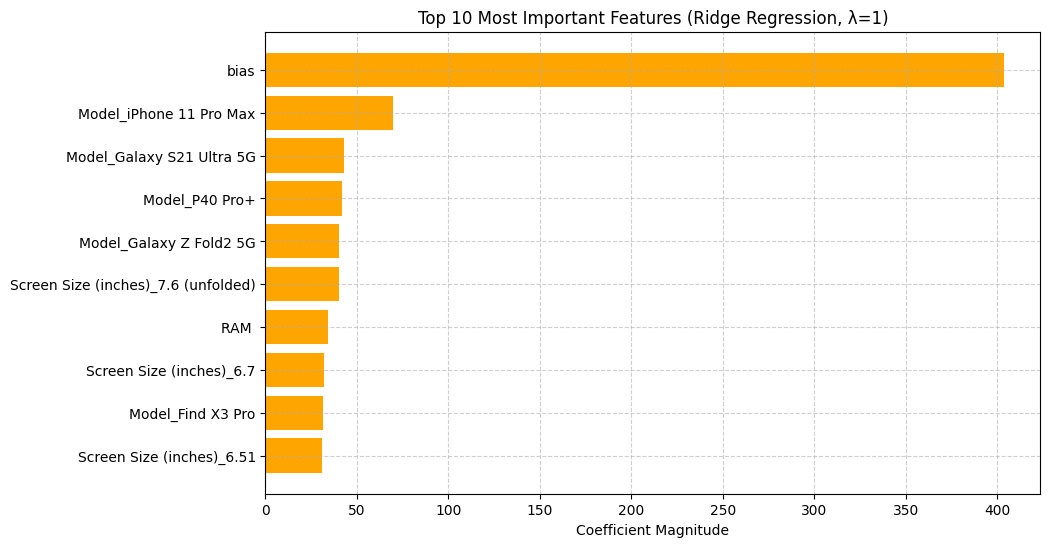

In [ ]:
#  FEATURE IMPORTANCE (Ridge Coefficients)
feature_names = ['bias'] + list(df.drop(columns=[target_col]).columns)
theta_final = ridge_closed_form(X_train_b, y_train, lambda_=1)
importance = np.abs(theta_final.flatten())
indices = np.argsort(importance)[-10:][::-1]

plt.figure(figsize=(10,6))
plt.barh(np.array(feature_names)[indices], importance[indices], color='orange')
plt.xlabel("Coefficient Magnitude")
plt.title("Top 10 Most Important Features (Ridge Regression, λ=1)")
plt.gca().invert_yaxis()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()



# BANK NOTE AUTHENTICATION - LINEAR CLASSIFICATION

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns


In [ ]:
file_path = "/content/drive/MyDrive/ML_LAB/TheoryAss-1/BankNote_Authentication.csv"

df = pd.read_csv(file_path)
print("Dataset loaded successfully!\n")
print(df.head(), "\nShape:", df.shape)


Dataset loaded successfully!

   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0 
Shape: (1372, 5)


In [ ]:
X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, "| Test shape:", X_test_scaled.shape)


Train shape: (1097, 4) | Test shape: (275, 4)



 Logistic Regression (No Regularization)
Train Accuracy: 0.9908842297174111
Test Accuracy: 0.9854545454545455

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99       153
           1       0.97      1.00      0.98       122

    accuracy                           0.99       275
   macro avg       0.98      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



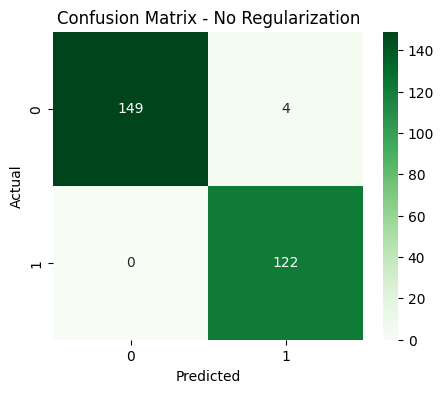

In [ ]:
#  LINEAR CLASSIFICATION (WITHOUT REGULARIZATION)
clf_no_reg = LogisticRegression(penalty=None, max_iter=1000)
clf_no_reg.fit(X_train_scaled, y_train)

y_pred_no_reg = clf_no_reg.predict(X_test_scaled)

acc_train_no_reg = accuracy_score(y_train, clf_no_reg.predict(X_train_scaled))
acc_test_no_reg = accuracy_score(y_test, y_pred_no_reg)

print("\n Logistic Regression (No Regularization)")
print("Train Accuracy:", acc_train_no_reg)
print("Test Accuracy:", acc_test_no_reg)
print("\nClassification Report:\n", classification_report(y_test, y_pred_no_reg))

# Confusion Matrix Plot
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_no_reg), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - No Regularization")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

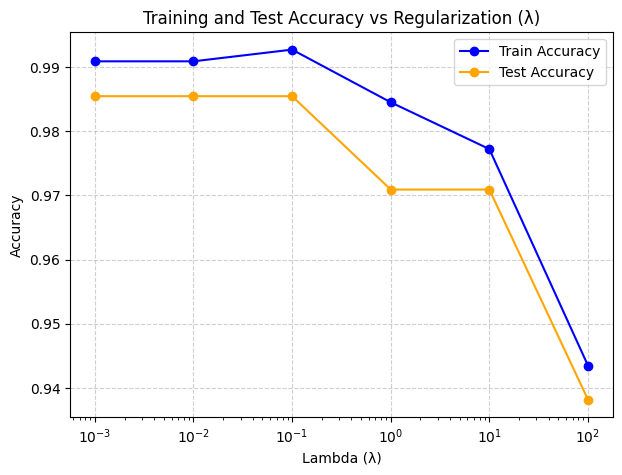


 Best λ = 0.001, Test Accuracy = 0.9855


In [ ]:
#  LINEAR CLASSIFICATION (WITH L2 REGULARIZATION)
lambdas = [0.001, 0.01, 0.1, 1, 10, 100]
train_acc = []
test_acc = []

for lam in lambdas:
    clf = LogisticRegression(C=1/lam, penalty='l2', solver='lbfgs', max_iter=1000)
    clf.fit(X_train_scaled, y_train)
    train_acc.append(accuracy_score(y_train, clf.predict(X_train_scaled)))
    test_acc.append(accuracy_score(y_test, clf.predict(X_test_scaled)))

# Accuracy Plot
plt.figure(figsize=(7,5))
plt.plot(lambdas, train_acc, marker='o', label='Train Accuracy', color='blue')
plt.plot(lambdas, test_acc, marker='o', label='Test Accuracy', color='orange')
plt.xscale('log')
plt.xlabel("Lambda (λ)")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy vs Regularization (λ)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

best_lambda = lambdas[np.argmax(test_acc)]
print(f"\n Best λ = {best_lambda}, Test Accuracy = {max(test_acc):.4f}")


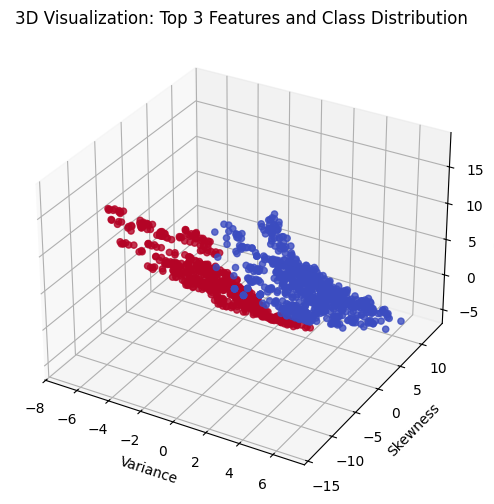

In [ ]:
# 3D VISUALIZATION OF DECISION REGIONS
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['variance'], df['skewness'], df['curtosis'],
           c=df['class'], cmap='coolwarm', alpha=0.8)
ax.set_xlabel("Variance")
ax.set_ylabel("Skewness")
ax.set_zlabel("Curtosis")
ax.set_title("3D Visualization: Top 3 Features and Class Distribution")
plt.show()


Added artificial outliers to 10 samples!


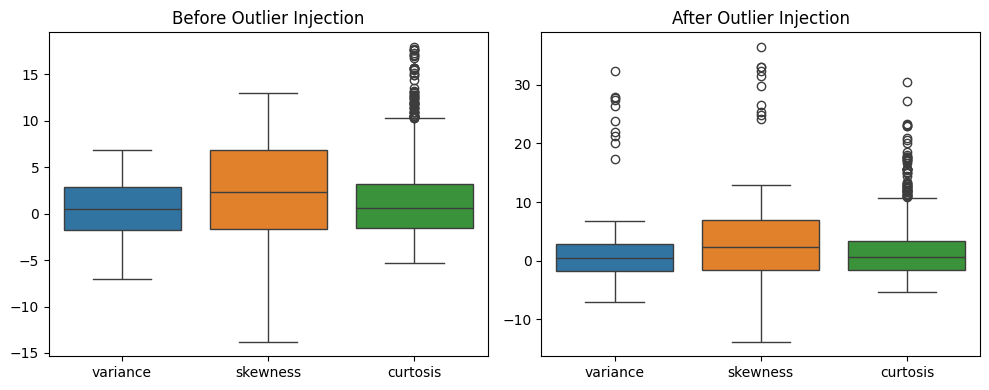

In [ ]:
df_outlier = df.copy()
outlier_indices = np.random.choice(df_outlier.index, size=10, replace=False)
df_outlier.loc[outlier_indices, ['variance', 'skewness', 'curtosis']] += np.random.uniform(20, 30, size=(10, 3))

print("\nAdded artificial outliers to 10 samples!")

# Plot before vs after outlier injection
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(data=df[['variance','skewness','curtosis']])
plt.title("Before Outlier Injection")

plt.subplot(1,2,2)
sns.boxplot(data=df_outlier[['variance','skewness','curtosis']])
plt.title("After Outlier Injection")
plt.tight_layout()
plt.show()



 After Outlier Injection:
Test Accuracy: 0.96
Impact on accuracy: 0.025454545454545507

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96       153
           1       0.94      0.98      0.96       122

    accuracy                           0.96       275
   macro avg       0.96      0.96      0.96       275
weighted avg       0.96      0.96      0.96       275



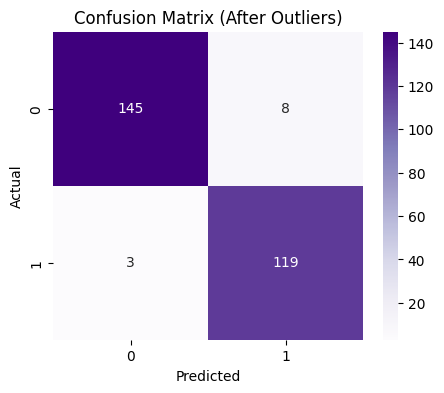

In [ ]:


X_out = df_outlier.drop(columns=['class'])
y_out = df_outlier['class']

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(X_out, y_out, test_size=0.2, random_state=42, stratify=y_out)

scaler_o = StandardScaler()
X_train_o = scaler_o.fit_transform(X_train_o)
X_test_o = scaler_o.transform(X_test_o)

clf_out = LogisticRegression(penalty='l2', C=1/best_lambda, solver='lbfgs', max_iter=1000)
clf_out.fit(X_train_o, y_train_o)

y_pred_out = clf_out.predict(X_test_o)
acc_out = accuracy_score(y_test_o, y_pred_out)

print("\n After Outlier Injection:")
print("Test Accuracy:", acc_out)
print("Impact on accuracy:", acc_test_no_reg - acc_out)
print("\nClassification Report:\n", classification_report(y_test_o, y_pred_out))

# Confusion Matrix Visualization
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test_o, y_pred_out), annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix (After Outliers)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


